# This notebook makes T-S diagrams of turbulent variables for both RREX Cruises

In [1]:
import xarray as xr
from scipy import io
import numpy as np
import pandas as pd
import seawater as sw
import matplotlib.pyplot as plt
import cmocean
import gsw
import os
import matplotlib.cm as cm
import matplotlib.colors as mcolors
#  this is just a useful function


def moving_average(x, n, window="flat"):
    if n % 2 == 0:
        n += 1
    N = x.size
    cx = np.full(x.size, np.nan)
    for i in range(N):
        ii = np.arange(i-n//2, i+n//2+1,1)
        if window == "flat":
            ww = np.ones(ii.size)
        elif window == "gauss":
            xx = ii - i
            ww = np.exp(- xx**2/(float(n)/4)**2 )
        elif window == "hanning":
            ww = np.hanning(ii.size)
        ww = ww[(ii >= 0) & (ii < N)]
        ii = ii[(ii >= 0) & (ii < N)]
        kk = np.isfinite(x[ii])
        if np.sum(kk) < 0.25*ii.size:
            continue
        cx[i] = np.sum(x[ii[kk]]*ww[kk])/np.sum(ww[kk])
    return cx

/tmp/ipykernel_8054/2184542827.py:5: UserWarning: The seawater library is deprecated! Please use gsw instead.
  import seawater as sw


# Loading the data for both cruises

In [2]:
target_dir = '/home/jovyan/NOC_NPD_Hackathon/PhD_Mixing/DataMerging' 
os.chdir(target_dir)

filename = ["RREX2015.mat", "RREX2017.mat"]
dsvmp2015 = io.loadmat(filename[0])
dsvmp2017 = io.loadmat(filename[1])

lon2015 = dsvmp2015["longitude"][0, :]  # Spatial coordinates
lat2015 = dsvmp2015["latitude"][0, :]
pres2015 = dsvmp2015["pres2d"][3:, 0].astype(float)
lon2017 = dsvmp2017["longitude"][0, :]
lat2017 = dsvmp2017["latitude"][0, :]
pres2017 = dsvmp2017["pres2d"][3:, 0].astype(float)

grT2015 = dsvmp2015["grT"][3:, :]  # 2015 variables
grS2015 = dsvmp2015["grS"][3:, :]
grO2015 = dsvmp2015["grO"][3:, :]
theta2015 = dsvmp2015["theta"][3:, :]
salinity2015 = dsvmp2015["salinity"][3:, :]
T2015 = dsvmp2015["T"][3:, :]
gamman2015 = dsvmp2015["gamman"][3:, :]
oxygen2015 = dsvmp2015["oxygen"][3:, :]
epsilon2015 = dsvmp2015["epsilon"][3:, :]
chi2015 = dsvmp2015["chi"][3:, :]

grT2017 = dsvmp2017["grT"][3:, :]  # 2017 variables
grS2017 = dsvmp2017["grS"][3:, :]
grO2017 = dsvmp2017["grO"][3:, :]
theta2017 = dsvmp2017["theta"][3:, :]
salinity2017 = dsvmp2017["salinity"][3:, :]
T2017 = dsvmp2017["T"][3:, :]
gamman2017 = dsvmp2017["gamman"][3:, :]
oxygen2017 = dsvmp2017["oxygen"][3:, :]
epsilon2017 = dsvmp2017["epsilon"][3:, :]
chi2017 = dsvmp2017["chi"][3:, :]

depth2015 = np.full(theta2015.shape, np.nan)  # Depth 2015
for i in range(lon2015.size):
    for j in range(pres2015.size):
        depth2015[j, i] = sw.dpth(pres2015[j], lat2015[i])

depth2017 = np.full(theta2017.shape, np.nan)  # Depth 2017
for i in range(lon2017.size):
    for j in range(pres2017.size):
        depth2017[j, i] = sw.dpth(pres2017[j], lat2017[i])

# Calculates TEOS-10 variables

In [3]:
pres2d2015 = np.tile(pres2015, (lon2015.size, 1)).T  # 2015
Lon2d2015 = np.tile(lon2015, (pres2015.size, 1))
Lat2d2015 = np.tile(lat2015, (pres2015.size, 1))
print(salinity2015.shape)
SA2015 = gsw.SA_from_SP(salinity2015, pres2d2015, Lon2d2015, Lat2d2015)
CT2015 = gsw.CT_from_pt(SA2015, theta2015)
sigma02015 = gsw.sigma0(SA2015, CT2015)+1000.
sp2015 = gsw.spiciness0(SA2015, CT2015)
gamman02015 = np.copy(gamman2015)

pres2d2017 = np.tile(pres2017, (lon2017.size, 1)).T  # 2017
Lon2d2017 = np.tile(lon2017, (pres2017.size, 1))
Lat2d2017 = np.tile(lat2017, (pres2017.size, 1))
print(salinity2017.shape)
SA2017 = gsw.SA_from_SP(salinity2017, pres2d2017, Lon2d2017, Lat2d2017)
CT2017 = gsw.CT_from_pt(SA2017, theta2017)
sigma02017 = gsw.sigma0(SA2017, CT2017)+1000.
sp2017 = gsw.spiciness0(SA2017, CT2017)
gamman02017 = np.copy(gamman2017)

(997, 58)
(997, 78)


/opt/conda/lib/python3.13/site-packages/gsw/_wrapped_ufuncs.py:1054: RuntimeWarning: invalid value encountered in ct_from_pt
  return _gsw_ufuncs.ct_from_pt(SA, pt)


# Calcutes $K_{\rho}$ using Osborn & Cox

In [4]:
# Calculate the _mean profiles in pressure coordinates instead of density ones

# 2015
theta_mean_2015 = np.full(theta2015.shape, np.nan)
salinity_mean_2015 = np.full(theta2015.shape, np.nan)
oxygen_mean_2015 = np.full(theta2015.shape, np.nan)

# Low pass method
n = 75  # Window ~ 300 meters
for i in range(lon2015.size):
    theta_mean_2015[:, i] = moving_average(theta2015[:, i], n, window="gauss")
    salinity_mean_2015[:, i] = moving_average(salinity2015[:, i], n, window="gauss")
    oxygen_mean_2015[:, i] = moving_average(oxygen2015[:, i], n, window="gauss")

grT_mean_2015 = np.full(theta2015.shape, np.nan)
grS_mean_2015 = np.full(theta2015.shape, np.nan)
grO_mean_2015 = np.full(theta2015.shape, np.nan)
for i in range(lon2015.size):
    for j in range(1, pres2015.size-1):
        grT_mean_2015[j, i] = -(theta_mean_2015[j+1, i] - theta_mean_2015[j-1, i])/(depth2015[j+1, i] - depth2015[j-1, i])
        grS_mean_2015[j, i] = -(salinity_mean_2015[j+1, i] - salinity_mean_2015[j-1, i])/(depth2015[j+1, i] - depth2015[j-1, i])
        grO_mean_2015[j, i] = -(oxygen_mean_2015[j+1, i] - oxygen_mean_2015[j-1, i])/(depth2015[j+1, i] - depth2015[j-1, i])

chi_oz_2015 = np.full(chi2015.shape, np.nan)
grT2_oz_2015 = np.full(chi2015.shape, np.nan)
grT22015 = grT2015**2

n = 15  # Window ~ 60 meters
for i in range(lon2015.size):
    chi_oz_2015[:, i] = moving_average(chi2015[:, i], n, window="gauss")
    grT2_oz_2015[:, i] = moving_average(grT22015[:, i], n, window="gauss")

Krho_2015 = chi_oz_2015/(2*grT2_oz_2015)  # diapycnal diffusivity

chi_dia_2015 = 2*Krho_2015*grT22015  # diapycnal production of thermal variance including fine scale: should be similar to chi
Pdia_2015 = 2*Krho_2015*grT_mean_2015**2  # diapycnal production of thermal on the mean flow profile
chiS_2015 = 2*Krho_2015*grS2015**2  # diapycnal production of haline variance including fine scale
chiS_2015[chiS_2015 > 1e-4] = np.nan  # removes some outlier
PdiaS_2015 = 2*Krho_2015*grS_mean_2015**2  # diapycnal production of haline on the mean flow profile
chiO_2015 = 2*Krho_2015*grO2015**2  # diapycnal production of oxygen variance including fine scale
PdiaO_2015 = 2*Krho_2015*grO_mean_2015**2  # diapycnal production of oxygen on the mean flow profile

# 2017
theta_mean_2017 = np.full(theta2017.shape, np.nan)
salinity_mean_2017 = np.full(theta2017.shape, np.nan)
oxygen_mean_2017 = np.full(theta2017.shape, np.nan)

# Low pass method
n = 75  # Window ~ 300 meters
for i in range(lon2017.size):
    theta_mean_2017[:, i] = moving_average(theta2017[:, i], n, window="gauss")
    salinity_mean_2017[:, i] = moving_average(salinity2017[:, i], n, window="gauss")
    oxygen_mean_2017[:, i] = moving_average(oxygen2017[:, i], n, window="gauss")

grT_mean_2017 = np.full(theta2017.shape, np.nan)
grS_mean_2017 = np.full(theta2017.shape, np.nan)
grO_mean_2017 = np.full(theta2017.shape, np.nan)
for i in range(lon2017.size):
    for j in range(1, pres2017.size-1):
        grT_mean_2017[j, i] = -(theta_mean_2017[j+1, i] - theta_mean_2017[j-1, i])/(depth2017[j+1, i] - depth2017[j-1, i])
        grS_mean_2017[j, i] = -(salinity_mean_2017[j+1, i] - salinity_mean_2017[j-1, i])/(depth2017[j+1, i] - depth2017[j-1, i])
        grO_mean_2017[j, i] = -(oxygen_mean_2017[j+1, i] - oxygen_mean_2017[j-1, i])/(depth2017[j+1, i] - depth2017[j-1, i])

chi_oz_2017 = np.full(chi2017.shape, np.nan)
grT2_oz_2017 = np.full(chi2017.shape, np.nan)
grT22017 = grT2017**2

n = 15  # Window ~ 60 meters
for i in range(lon2017.size):
    chi_oz_2017[:, i] = moving_average(chi2017[:, i], n, window="gauss")
    grT2_oz_2017[:, i] = moving_average(grT22017[:, i], n, window="gauss")

Krho_2017 = chi_oz_2017/(2*grT2_oz_2017)  # diapycnal diffusivity

chi_dia_2017 = 2*Krho_2017*grT22017  # diapycnal production of thermal variance including fine scale: should be similar to chi
Pdia_2017 = 2*Krho_2017*grT_mean_2017**2  # diapycnal production of thermal on the mean flow profile
chiS_2017 = 2*Krho_2017*grS2017**2  # diapycnal production of haline variance including fine scale
chiS_2017[chiS_2017 > 1e-4] = np.nan  # removes some outlier
PdiaS_2017 = 2*Krho_2017*grS_mean_2017**2  # diapycnal production of haline on the mean flow profile
chiO_2017 = 2*Krho_2017*grO2017**2  # diapycnal production of oxygen variance including fine scale
PdiaO_2017 = 2*Krho_2017*grO_mean_2017**2  # diapycnal production of oxygen on the mean flow profile

# Estimating the percent of diapycnal/total variance difussivity

In [5]:
# 2015
Ns = 30  # 120 meters
chi2015_smooth = np.full(chi2015.shape, np.nan) # Smoothing the array vertically
Pdia2015_smooth = np.full(chi2015.shape, np.nan)
chiS2015_smooth = np.full(chi2015.shape, np.nan)
PdiaS2015_smooth = np.full(chi2015.shape, np.nan)
chiO2015_smooth = np.full(chi2015.shape, np.nan)
PdiaO2015_smooth = np.full(chi2015.shape, np.nan)

for i in range(lon2015.size):
    chi2015_smooth[:, i] = moving_average(chi2015[:, i], Ns)
    Pdia2015_smooth[:, i] = moving_average(Pdia_2015[:, i], Ns)

    chiS2015_smooth[:, i] = moving_average(chiS_2015[:, i], Ns)
    PdiaS2015_smooth[:, i] = moving_average(PdiaS_2015[:, i], Ns)

    chiO2015_smooth[:, i] = moving_average(chiO_2015[:, i], Ns)
    PdiaO2015_smooth[:, i] = moving_average(PdiaO_2015[:, i], Ns)

theta_percent_2015 = np.round((Pdia2015_smooth/chi2015_smooth)*100, decimals=1)
Salt_percent_2015 = np.round((PdiaS2015_smooth/chiS2015_smooth)*100, decimals=1)
oxy_percent_2015 = np.round((PdiaO2015_smooth/chiO2015_smooth)*100, decimals=1)

# 2017
chi2017_smooth = np.full(chi2017.shape, np.nan)
Pdia2017_smooth = np.full(chi2017.shape, np.nan)
chiS2017_smooth = np.full(chi2017.shape, np.nan)
PdiaS2017_smooth = np.full(chi2017.shape, np.nan)
chiO2017_smooth = np.full(chi2017.shape, np.nan)
PdiaO2017_smooth = np.full(chi2017.shape, np.nan)

for i in range(lon2017.size):
    chi2017_smooth[:, i] = moving_average(chi2017[:, i], Ns)
    Pdia2017_smooth[:, i] = moving_average(Pdia_2017[:, i], Ns)

    chiS2017_smooth[:, i] = moving_average(chiS_2017[:, i], Ns)
    PdiaS2017_smooth[:, i] = moving_average(PdiaS_2017[:, i], Ns)

    chiO2017_smooth[:, i] = moving_average(chiO_2017[:, i], Ns)
    PdiaO2017_smooth[:, i] = moving_average(PdiaO_2017[:, i], Ns)

theta_percent_2017 = np.round((Pdia2017_smooth/chi2017_smooth)*100, decimals=1)
Salt_percent_2017 = np.round((PdiaS2017_smooth/chiS2017_smooth)*100, decimals=1)
oxy_percent_2017 = np.round((PdiaO2017_smooth/chiO2017_smooth)*100, decimals=1)

# Creating binned variables in T-S space

In [18]:
# Create bins for T-S grid
SA_bins = np.linspace(34.6, 35.45, 60)  # Adjust based on your data range
theta_bins = np.linspace(1, 11, 50)     # Adjust based on your data range

# 2015

# Bin the data
chi2015_grid = np.zeros((len(theta_bins)-1, len(SA_bins)-1))
chiS2015_grid = np.zeros((len(theta_bins)-1, len(SA_bins)-1))
chiO2015_grid = np.zeros((len(theta_bins)-1, len(SA_bins)-1))
theta2015_percent_grid = np.zeros((len(theta_bins)-1, len(SA_bins)-1))
salt2015_percent_grid = np.zeros((len(theta_bins)-1, len(SA_bins)-1))
oxy2015_percent_grid = np.zeros((len(theta_bins)-1, len(SA_bins)-1))
count2015_grid = np.zeros((len(theta_bins)-1, len(SA_bins)-1))

# Flatten arrays
SA2015_flat = SA2015.ravel()
theta2015_flat = theta2015.ravel()
chi2015_flat = chi2015_smooth.ravel()
chiS2015_flat = chiS2015_smooth.ravel()
chiO2015_flat = chiO2015_smooth.ravel()
theta2015_percent_flat = theta_percent_2015.ravel()
salt2015_percent_flat = Salt_percent_2015.ravel()
oxy2015_percent_flat = oxy_percent_2015.ravel()

# Remove NaNs
valid_mask = ~(np.isnan(SA2015_flat) | np.isnan(theta2015_flat) | np.isnan(chi2015_flat) | np.isnan(chiO2015_flat) | np.isnan(chiS2015_flat)
               | np.isnan(theta2015_percent_flat) | np.isnan(salt2015_percent_flat) | np.isnan(oxy2015_percent_flat))
SA2015_valid = SA2015_flat[valid_mask]
theta2015_valid = theta2015_flat[valid_mask]
chi2015_valid = chi2015_flat[valid_mask]
chiS2015_valid = chiS2015_flat[valid_mask]
chiO2015_valid = chiO2015_flat[valid_mask]
theta2015_percent_valid = theta2015_percent_flat[valid_mask]
salt2015_percent_valid = salt2015_percent_flat[valid_mask]
oxy2015_percent_valid = oxy2015_percent_flat[valid_mask]

# Bin the data
for i in range(len(SA2015_valid)):
    SA2015_idx = np.digitize(SA2015_valid[i], SA_bins) - 1  # finds which bin a value belongs to so it depends on
    theta2015_idx = np.digitize(theta2015_valid[i], theta_bins) - 1  # the actual value of SA and theta and the chosen bins (-1 for python indexing)
    
    if 0 <= SA2015_idx < chi2015_grid.shape[1] and 0 <= theta2015_idx < chi2015_grid.shape[0]:  # This checks if the indices are withn the grid boundaries
        chi2015_grid[theta2015_idx, SA2015_idx] += np.log10(chi2015_valid[i])  # We use += to sum all chi values inside the bin
        chiS2015_grid[theta2015_idx, SA2015_idx] += np.log10(chiS2015_valid[i])
        chiO2015_grid[theta2015_idx, SA2015_idx] += np.log10(chiO2015_valid[i])
        theta2015_percent_grid[theta2015_idx, SA2015_idx] += theta2015_percent_valid[i]
        salt2015_percent_grid[theta2015_idx, SA2015_idx] += salt2015_percent_valid[i]
        oxy2015_percent_grid[theta2015_idx, SA2015_idx] += oxy2015_percent_valid[i]
        count2015_grid[theta2015_idx, SA2015_idx] += 1 # Increment the bin counter to keep track of how many data points are containned in the bin

# Average the binned data
mask = count2015_grid > 0  # Makes a mask for bins with data
chi2015_grid[mask] /= count2015_grid[mask]  # Divides the summed values by the ammount of data per bin. is the same as: chi_grid = chi_grid / count_grid
chiS2015_grid[mask] /= count2015_grid[mask]
chiO2015_grid[mask] /= count2015_grid[mask]
theta2015_percent_grid[mask] /= count2015_grid[mask]
salt2015_percent_grid[mask] /= count2015_grid[mask]
oxy2015_percent_grid[mask] /= count2015_grid[mask]
chi2015_grid[~mask] = np.nan  # NaN for bin with no data
chiS2015_grid[~mask] = np.nan
chiO2015_grid[~mask] = np.nan
theta2015_percent_grid[~mask] = np.nan
salt2015_percent_grid[~mask] = np.nan
oxy2015_percent_grid[~mask] = np.nan

# 2017

# Bin the data
chi2017_grid = np.zeros((len(theta_bins)-1, len(SA_bins)-1))
chiS2017_grid = np.zeros((len(theta_bins)-1, len(SA_bins)-1))
chiO2017_grid = np.zeros((len(theta_bins)-1, len(SA_bins)-1))
theta2017_percent_grid = np.zeros((len(theta_bins)-1, len(SA_bins)-1))
salt2017_percent_grid = np.zeros((len(theta_bins)-1, len(SA_bins)-1))
oxy2017_percent_grid = np.zeros((len(theta_bins)-1, len(SA_bins)-1))
count2017_grid = np.zeros((len(theta_bins)-1, len(SA_bins)-1))

# Flatten arrays
SA2017_flat = SA2017.ravel()
theta2017_flat = theta2017.ravel()
chi2017_flat = chi2017_smooth.ravel()
chiS2017_flat = chiS2017_smooth.ravel()
chiO2017_flat = chiO2017_smooth.ravel()
theta2017_percent_flat = theta_percent_2017.ravel()
salt2017_percent_flat = Salt_percent_2017.ravel()
oxy2017_percent_flat = oxy_percent_2017.ravel()

# Remove NaNs
valid_mask = ~(np.isnan(SA2017_flat) | np.isnan(theta2017_flat) | np.isnan(chi2017_flat) | np.isnan(chiO2017_flat) | np.isnan(chiS2017_flat)
               | np.isnan(theta2017_percent_flat) | np.isnan(salt2017_percent_flat) | np.isnan(oxy2017_percent_flat))
SA2017_valid = SA2017_flat[valid_mask]
theta2017_valid = theta2017_flat[valid_mask]
chi2017_valid = chi2017_flat[valid_mask]
chiS2017_valid = chiS2017_flat[valid_mask]
chiO2017_valid = chiO2017_flat[valid_mask]
theta2017_percent_valid = theta2017_percent_flat[valid_mask]
salt2017_percent_valid = salt2017_percent_flat[valid_mask]
oxy2017_percent_valid = oxy2017_percent_flat[valid_mask]

# Bin the data
for i in range(len(SA2017_valid)):
    SA2017_idx = np.digitize(SA2017_valid[i], SA_bins) - 1
    theta2017_idx = np.digitize(theta2017_valid[i], theta_bins) - 1
    
    if 0 <= SA2017_idx < chi2017_grid.shape[1] and 0 <= theta2017_idx < chi2017_grid.shape[0]:
        chi2017_grid[theta2017_idx, SA2017_idx] += np.log10(chi2017_valid[i])
        chiS2017_grid[theta2017_idx, SA2017_idx] += np.log10(chiS2017_valid[i])
        chiO2017_grid[theta2017_idx, SA2017_idx] += np.log10(chiO2017_valid[i])
        theta2017_percent_grid[theta2017_idx, SA2017_idx] += theta2017_percent_valid[i]
        salt2017_percent_grid[theta2017_idx, SA2017_idx] += salt2017_percent_valid[i]
        oxy2017_percent_grid[theta2017_idx, SA2017_idx] += oxy2017_percent_valid[i]
        count2017_grid[theta2017_idx, SA2017_idx] += 1

# Average the binned data
mask = count2017_grid > 0  # Makes a mask for bins with data
chi2017_grid[mask] /= count2017_grid[mask]  # Divides the summed values by the ammount of data per bin. is the same as: chi_grid = chi_grid / count_grid
chiS2017_grid[mask] /= count2017_grid[mask]
chiO2017_grid[mask] /= count2017_grid[mask]
theta2017_percent_grid[mask] /= count2017_grid[mask]
salt2017_percent_grid[mask] /= count2017_grid[mask]
oxy2017_percent_grid[mask] /= count2017_grid[mask]
chi2017_grid[~mask] = np.nan  # NaN for bin with no data
chiS2017_grid[~mask] = np.nan
chiO2017_grid[~mask] = np.nan
theta2017_percent_grid[~mask] = np.nan
salt2017_percent_grid[~mask] = np.nan
oxy2017_percent_grid[~mask] = np.nan

# Ploting turbulence in T-S space

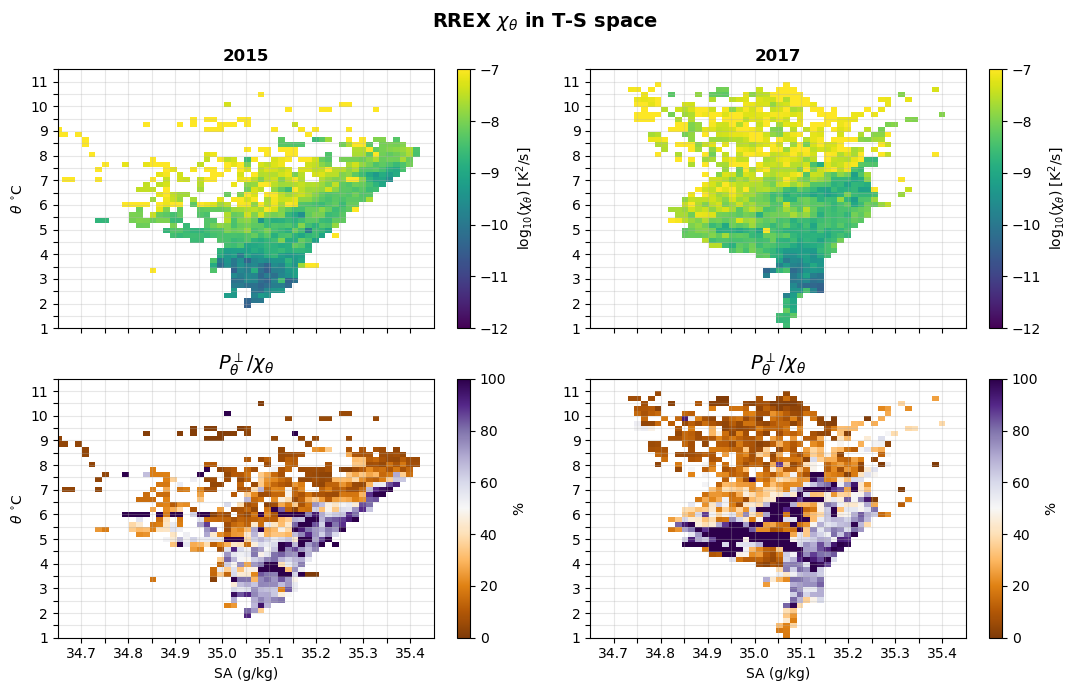

In [52]:
fig, ax = plt.subplots(2, 2, sharex=True, sharey=True, figsize=(11, 7))

tick_positions_theta = np.arange(1, 12, 0.5)
tick_labels_theta = [f'{val:.0f}' if i % 2 == 0 else '' for i, val in enumerate(tick_positions_theta)] # Set labels only for every other tick (7 labels)

tick_positions_salt = np.arange(34.7, 35.45, 0.05)
tick_labels_salt = [f'{val:.1f}' if i % 2 == 0 else '' for i, val in enumerate(tick_positions_salt)]

# Thermal Data

cc = ax[0, 0].pcolormesh(SA_bins, theta_bins, chi2015_grid,
                   vmin=-12, vmax=-7, shading='auto')
plt.colorbar(cc, ax=ax[0, 0], label='log$_{10}$($\\chi_{\\theta}$) [K$^2$/s]')
ax[0,0].set_title('2015', fontsize=12, fontweight='bold')
ax[0,0].grid(True, alpha=0.3, which='both')
ax[0,0].set_ylim((1, 11))
ax[0,0].set_xlim((34.65, 35.45))
ax[0,0].set_ylabel("$\\theta$ $^{\\circ}$C")
ax[0,0].set_yticks(tick_positions_theta)
ax[0,0].set_yticklabels(tick_labels_theta)

cc = ax[1, 0].pcolormesh(SA_bins, theta_bins, theta2015_percent_grid, 
                   cmap=cm.PuOr, vmin=0, vmax=100, shading='auto')
plt.colorbar(cc, ax=ax[1, 0], label='%')
ax[1,0].set_title('$P_{\\theta}^{\\perp}/\\chi_{\\theta}$', fontsize=14)
ax[1,0].set_ylabel("$\\theta$ $^{\\circ}$C")
ax[1,0].set_xlabel('SA (g/kg)')
ax[1,0].set_xticks(tick_positions_salt)
ax[1,0].set_xticklabels(tick_labels_salt)
ax[1,0].grid(True, alpha=0.3, which='both')

cc = ax[0, 1].pcolormesh(SA_bins, theta_bins, chi2017_grid,
                   vmin=-12, vmax=-7, shading='auto')
plt.colorbar(cc, ax=ax[0, 1], label='log$_{10}$($\\chi_{\\theta}$) [K$^2$/s]')
ax[0,1].set_title('2017', fontsize=12, fontweight='bold')
ax[0,1].set_yticklabels(tick_labels_theta)
ax[0,1].grid(True, alpha=0.3, which='both')

cc = ax[1, 1].pcolormesh(SA_bins, theta_bins, theta2017_percent_grid, 
                   cmap=cm.PuOr, vmin=0, vmax=100, shading='auto')
plt.colorbar(cc, ax=ax[1, 1], label='%')
ax[1,1].set_title('$P_{\\theta}^{\\perp}/\\chi_{\\theta}$', fontsize=14)
ax[1,1].set_xlabel('SA (g/kg)')
ax[1,1].set_xticklabels(tick_labels_salt)
ax[1,1].set_yticklabels(tick_labels_theta)
ax[1,1].grid(True, alpha=0.3, which='both')

# After all plotting, ensure y-axis labels are visible
for row in range(2):
    for col in range(2):
        ax[row, col].tick_params(axis='y', labelleft=True)  # Show y-tick labels

plt.suptitle('RREX $\\chi_{\\theta}$ in T-S space',fontsize=14,fontweight='bold',y=0.98)
fig.tight_layout()
plt.show()

fig.savefig('RREX_TS_theta', dpi=300, bbox_inches="tight")

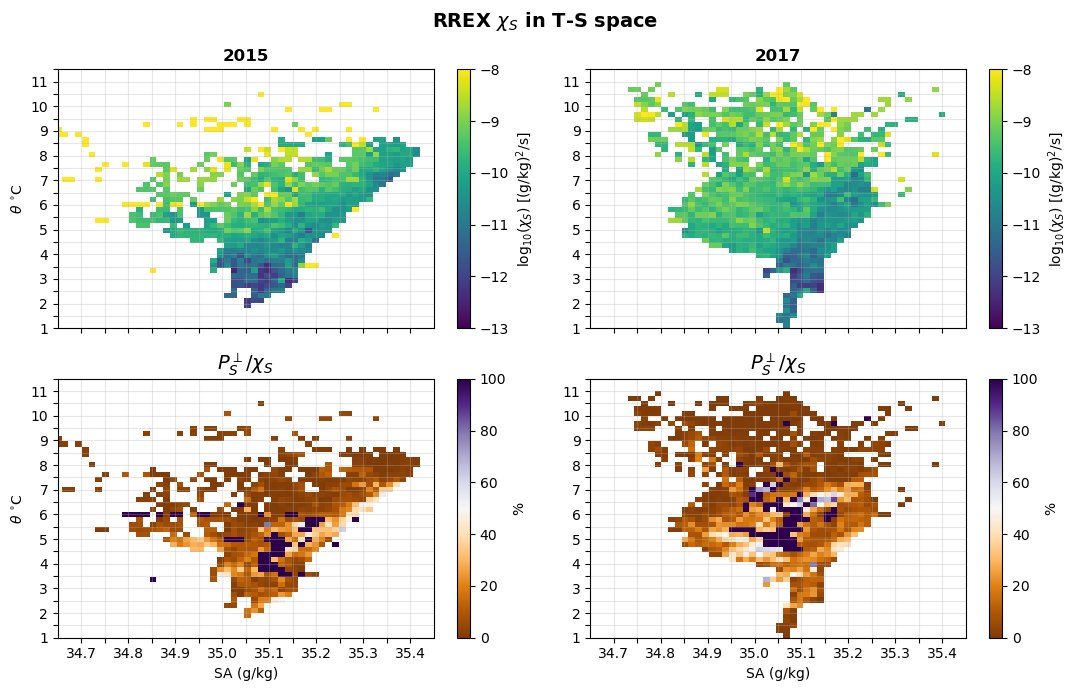

In [51]:
fig, ax = plt.subplots(2, 2, sharex=True, sharey=True, figsize=(11, 7))

# Haline Data

cc = ax[0, 0].pcolormesh(SA_bins, theta_bins, chiS2015_grid,
                   vmin=-13, vmax=-8, shading='auto')
plt.colorbar(cc, ax=ax[0, 0], label='log$_{10}$($\\chi_S$) [(g/kg)$^2$/s]')
ax[0,0].set_title('2015', fontsize=12, fontweight='bold')
ax[0,0].grid(True, alpha=0.3, which='both')
ax[0,0].set_ylim((1, 11))
ax[0,0].set_xlim((34.65, 35.45))
ax[0,0].set_ylabel("$\\theta$ $^{\\circ}$C")
tick_positions = np.arange(1, 12, 0.5)
tick_labels = [f'{val:.0f}' if i % 2 == 0 else '' for i, val in enumerate(tick_positions)] # Set labels only for every other tick (7 labels)
ax[0,0].set_yticks(tick_positions)
ax[0,0].set_yticklabels(tick_labels)

cc = ax[1, 0].pcolormesh(SA_bins, theta_bins, salt2015_percent_grid, 
                   cmap=cm.PuOr, vmin=0, vmax=100, shading='auto')
plt.colorbar(cc, ax=ax[1, 0], label='%')
ax[1,0].set_title('$P_{S}^{\\perp}/\\chi_{S}$', fontsize=14)
ax[1,0].set_ylabel("$\\theta$ $^{\\circ}$C")
ax[1,0].set_xlabel('SA (g/kg)')
tick_positions = np.arange(34.7, 35.45, 0.05)
tick_labels = [f'{val:.1f}' if i % 2 == 0 else '' for i, val in enumerate(tick_positions)] # Set labels only for every other tick 
ax[1,0].set_xticks(tick_positions)
ax[1,0].set_xticklabels(tick_labels)
ax[1,0].grid(True, alpha=0.3, which='both')

cc = ax[0, 1].pcolormesh(SA_bins, theta_bins, chiS2017_grid,
                   vmin=-13, vmax=-8, shading='auto')
plt.colorbar(cc, ax=ax[0, 1], label='log$_{10}$($\\chi_S$) [(g/kg)$^2$/s]')
ax[0,1].set_title('2017', fontsize=12, fontweight='bold')
ax[0,1].grid(True, alpha=0.3, which='both')


cc = ax[1, 1].pcolormesh(SA_bins, theta_bins, salt2017_percent_grid, 
                   cmap=cm.PuOr, vmin=0, vmax=100, shading='auto')
plt.colorbar(cc, ax=ax[1, 1], label='%')
ax[1,1].set_title('$P_{S}^{\\perp}/\\chi_{S}$', fontsize=14)
ax[1,1].set_xlabel('SA (g/kg)')
ax[1,1].set_xticklabels(tick_labels)
ax[1,1].grid(True, alpha=0.3, which='both')

# After all plotting, ensure y-axis labels are visible
for row in range(2):
    for col in range(2):
        ax[row, col].tick_params(axis='y', labelleft=True)  # Show y-tick labels

plt.suptitle('RREX $\\chi_S$ in T-S space',fontsize=14,fontweight='bold',y=0.98)
fig.tight_layout()
plt.show()

fig.savefig('RREX_TS_salt', dpi=300, bbox_inches="tight")

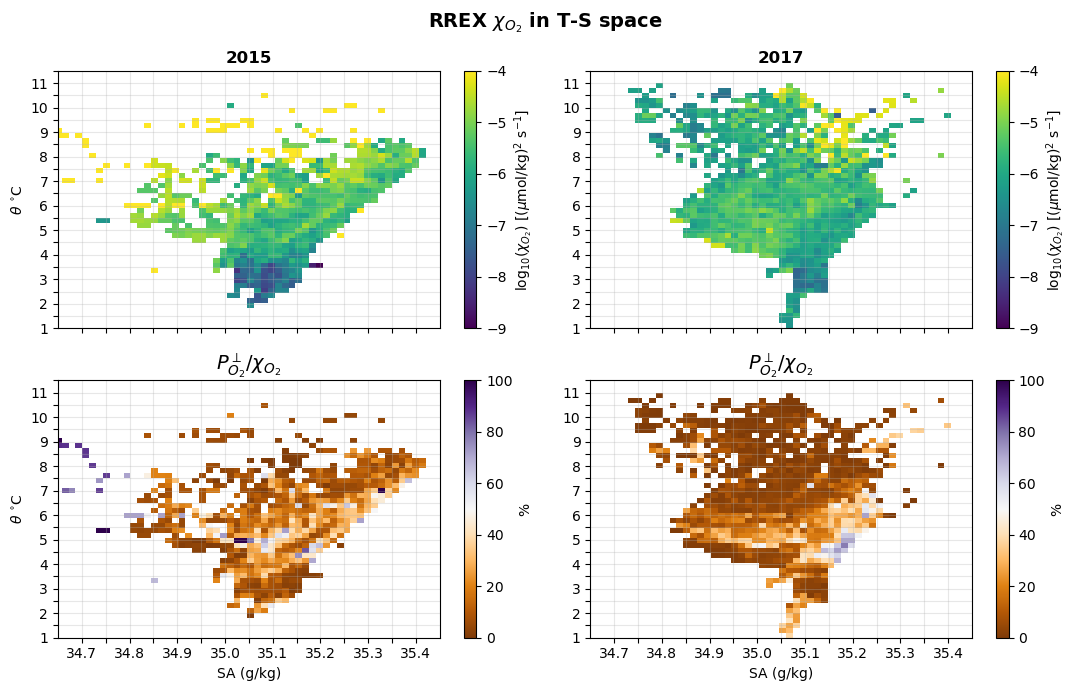

In [50]:
fig, ax = plt.subplots(2, 2, sharex=True, sharey=True, figsize=(11, 7))

# Oxygen Data

cc = ax[0, 0].pcolormesh(SA_bins, theta_bins, chiO2015_grid,
                   vmin=-9, vmax=-4, shading='auto')
plt.colorbar(cc, ax=ax[0, 0], label='log$_{10}$($\\chi_{O_2}$) [($\\mu$mol/kg)$^2$ s$^{-1}$]')
ax[0,0].set_title('2015', fontsize=12, fontweight='bold')
ax[0,0].grid(True, alpha=0.3, which='both')
ax[0,0].set_ylim((1, 11))
ax[0,0].set_xlim((34.65, 35.45))
ax[0,0].set_ylabel("$\\theta$ $^{\\circ}$C")
tick_positions = np.arange(1, 12, 0.5)
tick_labels = [f'{val:.0f}' if i % 2 == 0 else '' for i, val in enumerate(tick_positions)] # Set labels only for every other tick (7 labels)
ax[0,0].set_yticks(tick_positions_theta)
ax[0,0].set_yticklabels(tick_labels_theta)

cc = ax[1, 0].pcolormesh(SA_bins, theta_bins, oxy2015_percent_grid, 
                   cmap=cm.PuOr, vmin=0, vmax=100, shading='auto')
plt.colorbar(cc, ax=ax[1, 0], label='%')
ax[1,0].set_title('$P_{O_2}^{\\perp}/\\chi_{O_2}$', fontsize=14)
ax[1,0].set_ylabel("$\\theta$ $^{\\circ}$C")
ax[1,0].set_xlabel('SA (g/kg)')
tick_positions = np.arange(34.7, 35.45, 0.05)
tick_labels = [f'{val:.1f}' if i % 2 == 0 else '' for i, val in enumerate(tick_positions)] # Set labels only for every other tick 
ax[1,0].set_xticks(tick_positions_salt)
ax[1,0].set_xticklabels(tick_labels_salt)
ax[1,0].grid(True, alpha=0.3, which='both')

cc = ax[0, 1].pcolormesh(SA_bins, theta_bins, chiO2017_grid,
                   vmin=-9, vmax=-4, shading='auto')
plt.colorbar(cc, ax=ax[0, 1], label='log$_{10}$($\\chi_{O_2}$) [($\\mu$mol/kg)$^2$ s$^{-1}$]')
ax[0,1].set_title('2017', fontsize=12, fontweight='bold')
ax[0,1].grid(True, alpha=0.3, which='both')


cc = ax[1, 1].pcolormesh(SA_bins, theta_bins, oxy2017_percent_grid, 
                   cmap=cm.PuOr, vmin=0, vmax=100, shading='auto')
plt.colorbar(cc, ax=ax[1, 1], label='%')
ax[1,1].set_title('$P_{O_2}^{\\perp}/\\chi_{O_2}$', fontsize=14)
ax[1,1].set_xlabel('SA (g/kg)')
ax[1,1].set_xticklabels(tick_labels_salt)
ax[1,1].grid(True, alpha=0.3, which='both')
ax[1,1].set_yticklabels(tick_labels_theta)

# After all plotting, ensure y-axis labels are visible
for row in range(2):
    for col in range(2):
        ax[row, col].tick_params(axis='y', labelleft=True)  # Show y-tick labels

plt.suptitle('RREX $\\chi_{O_2}$ in T-S space',fontsize=14,fontweight='bold',y=0.98)
fig.tight_layout()
plt.show()

fig.savefig('RREX_TS_oxy', dpi=300, bbox_inches="tight")